In [2]:
import yfinance as yf

In [3]:
!pip3 install numpy

In [4]:
import numpy as np

In [5]:
import sys

In [6]:
sp500 = yf.Ticker("^GSPC")

In [7]:
sp500 = sp500.history(period="max")

In [8]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-07-22 00:00:00-04:00', '2025-07-23 00:00:00-04:00',
               '2025-07-24 00:00:00-04:00', '2025-07-25 00:00:00-04:00',
               '2025-07-28 00:00:00-04:00', '2025-07-29 00:00:00-04:00',
               '2025-07-30 00:00:00-04:00', '2025-07-31 00:00:00-04:00',
               '2025-08-01 00:00:00-04:00', '2025-08-04 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24513, freq=None)

<Axes: xlabel='Date'>

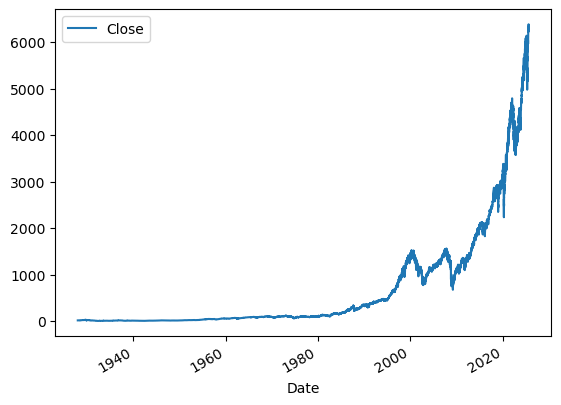

In [9]:
sp500.plot.line(y="Close", use_index=True)

In [10]:
del sp500["Dividends"]

In [11]:
del sp500["Stock Splits"]

In [12]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [13]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
#target is "1" if tomorrow's price increased and "0" if it decreased

In [14]:
#removes all rows before Jan 1, 1990
sp500 = sp500.loc["1990-01-01":].copy()

In [15]:
!pip install --upgrade --force-reinstall numpy scipy scikit-learn

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl (20.9 MB)
Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl (8.6 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully

In [16]:
import sklearn

In [17]:
from sklearn.ensemble import RandomForestClassifier
#Random forest are more resistent to overfitting

# Incerased n_esitmators improves accuracy up to a cetain point. 
# min_samples_split helps stop overfitting but decreases accuracy
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
RandomForestClassifier(min_samples_split=100, random_state=1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
from sklearn.metrics import precision_score
# How accurate was the model when predicting "Target" if it will go up (percent)

preds = model.predict(test[predictors])

In [20]:
import pandas as pd

In [21]:
preds = pd.Series(preds, index=test.index)

In [22]:
precision_score(test["Target"], preds)

0.5915492957746479

In [23]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

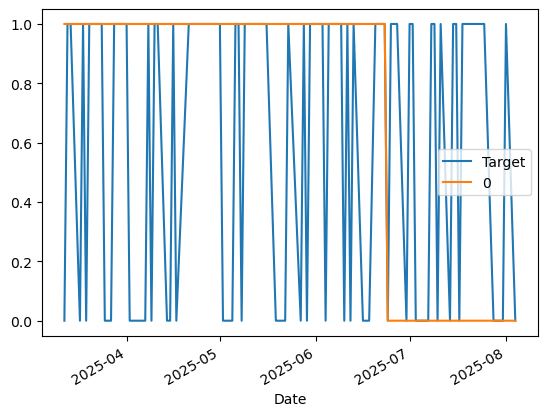

In [24]:
combined.plot()

In [25]:

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict(test[predictors]) #generates predictions
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [26]:
def backtest(data, model, predictors, start=2500, step=250): #start=2500 means train the first model with 10 years of data
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [27]:
predictions = backtest(sp500, model, predictors)

In [28]:
predictions["Predictions"].value_counts()

Predictions
0    3731
1    2732
Name: count, dtype: int64

In [29]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5281844802342606

In [30]:
predictions["Target"].value_counts() / predictions.shape[0] #this is the actual percentange of if it went up or down


Target
1    0.536748
0    0.463252
Name: count, dtype: float64

In [31]:
horizons = [2,5,60,250,1000] #calc mean close price in the last 2 days, 5 days, 3 months, etc...
new_predictors = []

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500 ["Close"] / rolling_average["Close"]

    trend_column =f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [32]:
sp500 = sp500.dropna()

In [33]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28 00:00:00-04:00,6397.689941,6401.069824,6375.790039,6389.770020,4565620000,6370.859863,0,1.000088,2.0,1.004356,5.0,1.058849,38.0,1.097186,145.0,1.337445,533.0
2025-07-29 00:00:00-04:00,6405.620117,6409.259766,6363.919922,6370.859863,5076120000,6362.899902,0,0.998518,1.0,0.999459,4.0,1.053485,37.0,1.093257,144.0,1.332944,532.0
2025-07-30 00:00:00-04:00,6381.229980,6396.540039,6336.379883,6362.899902,5375070000,6339.390137,0,0.999375,0.0,0.998086,3.0,1.050211,36.0,1.091197,144.0,1.330733,532.0


In [34]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [35]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict_proba(test[predictors])[:,1] #gives the probability of the stock going up
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [36]:
predictions = backtest(sp500, model, new_predictors)

In [37]:
predictions["Predictions"].value_counts()

Predictions
0.0    4593
1.0     869
Name: count, dtype: int64

In [38]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5742232451093211

In [39]:
#now I want to train the model on CPI, PPI, Unemployment, GDP, and the fed interest rates.

In [40]:
!pip install fredapi

In [41]:
%pip install --upgrade --force-reinstall numpy pandas

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl (10.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found e

In [42]:
from fredapi import Fred

In [43]:
fred = Fred(api_key='1589088aac5d668a6d59c92eb458255e')

In [44]:
cpi = fred.get_series('CPIAUCSL')           # Consumer Price Index
ppi = fred.get_series('PPIACO')             # Producer Price Index
unemployment = fred.get_series('UNRATE')    # Unemployment rate
gdp = fred.get_series('A191RL1Q225SBEA')     # Real GDP Growth (percent change)
interest_rate = fred.get_series('FEDFUNDS') # Federal Funds Rate

In [45]:
#cutting off all dates before 1993-12-01
cpi = cpi.loc["1993-12-01":].copy()
ppi = ppi.loc["1993-12-01":].copy()
unemployment = unemployment.loc["1993-12-01":].copy()
gdp = gdp.loc["1993-12-01":].copy()
interest_rate = interest_rate.loc["1993-12-01":].copy()

In [46]:
cpi = cpi.rename('CPI')
ppi = ppi.rename('PPI')
gdp = gdp.rename('GDP')
unemployment = unemployment.rename('Unemployment')
interest_rate = interest_rate.rename('InterestRate')

In [47]:
cpi = cpi.resample('D').ffill()  # Forward-fill cpi data to each day
ppi = ppi.resample('D').ffill()  # Forward-fill ppi data to each day
unemployment = unemployment.resample('D').ffill()  # Forward-fill unemployment data to each day
interest_rate = interest_rate.resample('D').ffill()  # Forward-fill interest rate data to each day
gdp = gdp.resample('D').ffill()  # Forward-fill macro data to each day

In [48]:
cpi.index

DatetimeIndex(['1993-12-01', '1993-12-02', '1993-12-03', '1993-12-04',
               '1993-12-05', '1993-12-06', '1993-12-07', '1993-12-08',
               '1993-12-09', '1993-12-10',
               ...
               '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26',
               '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30',
               '2025-05-31', '2025-06-01'],
              dtype='datetime64[ns]', length=11506, freq='D')

In [49]:
sp500.index = sp500.index.tz_localize(None)

In [50]:
sp500.index

DatetimeIndex(['1993-12-14', '1993-12-15', '1993-12-16', '1993-12-17',
               '1993-12-20', '1993-12-21', '1993-12-22', '1993-12-23',
               '1993-12-27', '1993-12-28',
               ...
               '2025-07-21', '2025-07-22', '2025-07-23', '2025-07-24',
               '2025-07-25', '2025-07-28', '2025-07-29', '2025-07-30',
               '2025-07-31', '2025-08-01'],
              dtype='datetime64[ns]', name='Date', length=7962, freq=None)

In [51]:
sp500 = sp500.join([cpi, ppi, gdp, unemployment, interest_rate], how='left')

In [60]:
#adds data for the specified dates so GDP data begins and ends at the same time as all the other data.
sp500.loc['1993-12-14':'1994-01-01', 'GDP'] = 2.8
sp500.loc['2025-01-02':'2025-03-31', 'GDP'] = -0.5
sp500.loc['2025-04-01':'2025-06-30', 'GDP'] = 3
sp500.loc['2025-06-01':'2025-06-30', 'CPI'] = 321.50
sp500.loc['2025-06-01':'2025-06-30', 'PPI'] = 260.180
sp500.loc['2025-07-01':'2025-07-31', 'Unemployment'] = 4.2
sp500.loc['2025-07-01':'2025-07-31', 'InterestRate'] = 4.33

In [53]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000,CPI,PPI,GDP,Unemployment,InterestRate
Date,,,,,,,,,,,,,,,,,,,,,
1993-12-14,465.730011,466.119995,462.459991,463.059998,2.750500e+08,461.839996,0.0,0.997157,1.0,0.996617,...,32.0,1.028047,127.0,1.176082,512.0,146.3,118.6,2.8,6.5,2.96
1993-12-15,463.059998,463.690002,461.839996,461.839996,3.317700e+08,463.339996,1.0,0.998681,0.0,0.995899,...,32.0,1.025151,126.0,1.172676,512.0,146.3,118.6,2.8,6.5,2.96
1993-12-16,461.859985,463.980011,461.859985,463.339996,2.846200e+08,466.380005,1.0,1.001621,1.0,0.999495,...,32.0,1.028274,127.0,1.176163,513.0,146.3,118.6,2.8,6.5,2.96
1993-12-17,463.339996,466.380005,463.339996,466.380005,3.637500e+08,465.850006,0.0,1.003270,2.0,1.004991,...,32.0,1.034781,128.0,1.183537,514.0,146.3,118.6,2.8,6.5,2.96
1993-12-20,466.380005,466.899994,465.529999,465.850006,2.559000e+08,465.299988,0.0,0.999431,1.0,1.003784,...,32.0,1.033359,128.0,1.181856,513.0,146.3,118.6,2.8,6.5,2.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28,6397.689941,6401.069824,6375.790039,6389.770020,4.565620e+09,6370.859863,0.0,1.000088,2.0,1.004356,...,38.0,1.097186,145.0,1.337445,533.0,NaN,NaN,NaN,NaN,NaN
2025-07-29,6405.620117,6409.259766,6363.919922,6370.859863,5.076120e+09,6362.899902,0.0,0.998518,1.0,0.999459,...,37.0,1.093257,144.0,1.332944,532.0,NaN,NaN,NaN,NaN,NaN
2025-07-30,6381.229980,6396.540039,6336.379883,6362.899902,5.375070e+09,6339.390137,0.0,0.999375,0.0,0.998086,...,36.0,1.091197,144.0,1.330733,532.0,NaN,NaN,NaN,NaN,NaN


In [61]:
sp500['InterestRate']

Date
1993-12-14    2.96
1993-12-15    2.96
1993-12-16    2.96
1993-12-17    2.96
1993-12-20    2.96
              ... 
2025-07-28    4.33
2025-07-29    4.33
2025-07-30    4.33
2025-07-31    4.33
2025-08-01     NaN
Name: InterestRate, Length: 7962, dtype: float64

In [84]:
sp500 = sp500.dropna()

In [101]:
horizons = [2,5,60,250,1000]
predictors3 = ["CPI", "PPI", "GDP", "Unemployment", "InterestRate"]

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500.loc[:, ratio_column] = sp500["Close"] / rolling_average["Close"]

    trend_column = f"Trend_{horizon}"
    sp500.loc[:, trend_column] = sp500["Target"].shift(1).rolling(horizon).sum()

    predictors3 += [ratio_column, trend_column]


In [102]:
model3 = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

model3.fit(train[predictors3], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000,CPI,PPI,GDP,Unemployment,InterestRate
Date,,,,,,,,,,,,,,,,,,,,,
1997-11-26,950.820007,956.469971,950.820007,951.640015,4.877500e+08,955.400024,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,161.7,127.90,3.5,4.6,5.52
1997-11-28,951.640015,959.130005,951.640015,955.400024,1.890700e+08,974.770020,1.0,1.001972,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,161.7,127.90,3.5,4.6,5.52
1997-12-01,955.400024,974.770020,955.400024,974.770020,5.903000e+08,971.679993,0.0,1.010035,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,161.8,126.80,3.5,4.7,5.50
1997-12-02,974.780029,976.200012,969.830017,971.679993,5.761200e+08,976.770020,1.0,0.998412,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,161.8,126.80,3.5,4.7,5.50
1997-12-03,971.679993,980.809998,966.159973,976.770020,6.246100e+08,973.099976,0.0,1.002612,1.0,1.011095,...,NaN,NaN,NaN,NaN,NaN,161.8,126.80,3.5,4.7,5.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,6061.209961,6101.759766,6059.250000,6092.180176,5.443690e+09,6092.160156,0.0,1.005530,2.0,1.013715,...,36.0,1.058266,144.0,1.286939,530.0,321.5,260.18,3.0,4.1,4.33
2025-06-25,6104.229980,6108.509766,6080.089844,6092.160156,5.171110e+09,6141.020020,1.0,0.999998,1.0,1.010033,...,36.0,1.057805,143.0,1.286447,529.0,321.5,260.18,3.0,4.1,4.33
2025-06-26,6112.089844,6146.520020,6107.270020,6141.020020,5.308140e+09,6173.069824,1.0,1.003994,1.0,1.012756,...,36.0,1.065798,143.0,1.296266,529.0,321.5,260.18,3.0,4.1,4.33


In [103]:
predictions = backtest(sp500, model3, predictors3)

In [104]:
predictions["Predictions"].value_counts()

Predictions
0.0    3965
1.0     474
Name: count, dtype: int64

In [105]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5611814345991561